In [1]:
import torch
import torch.nn as nn
from dataclasses import dataclass
import torch.nn.functional as F
import math

from ROPE import ROPE, apply_rotary_pos_emb

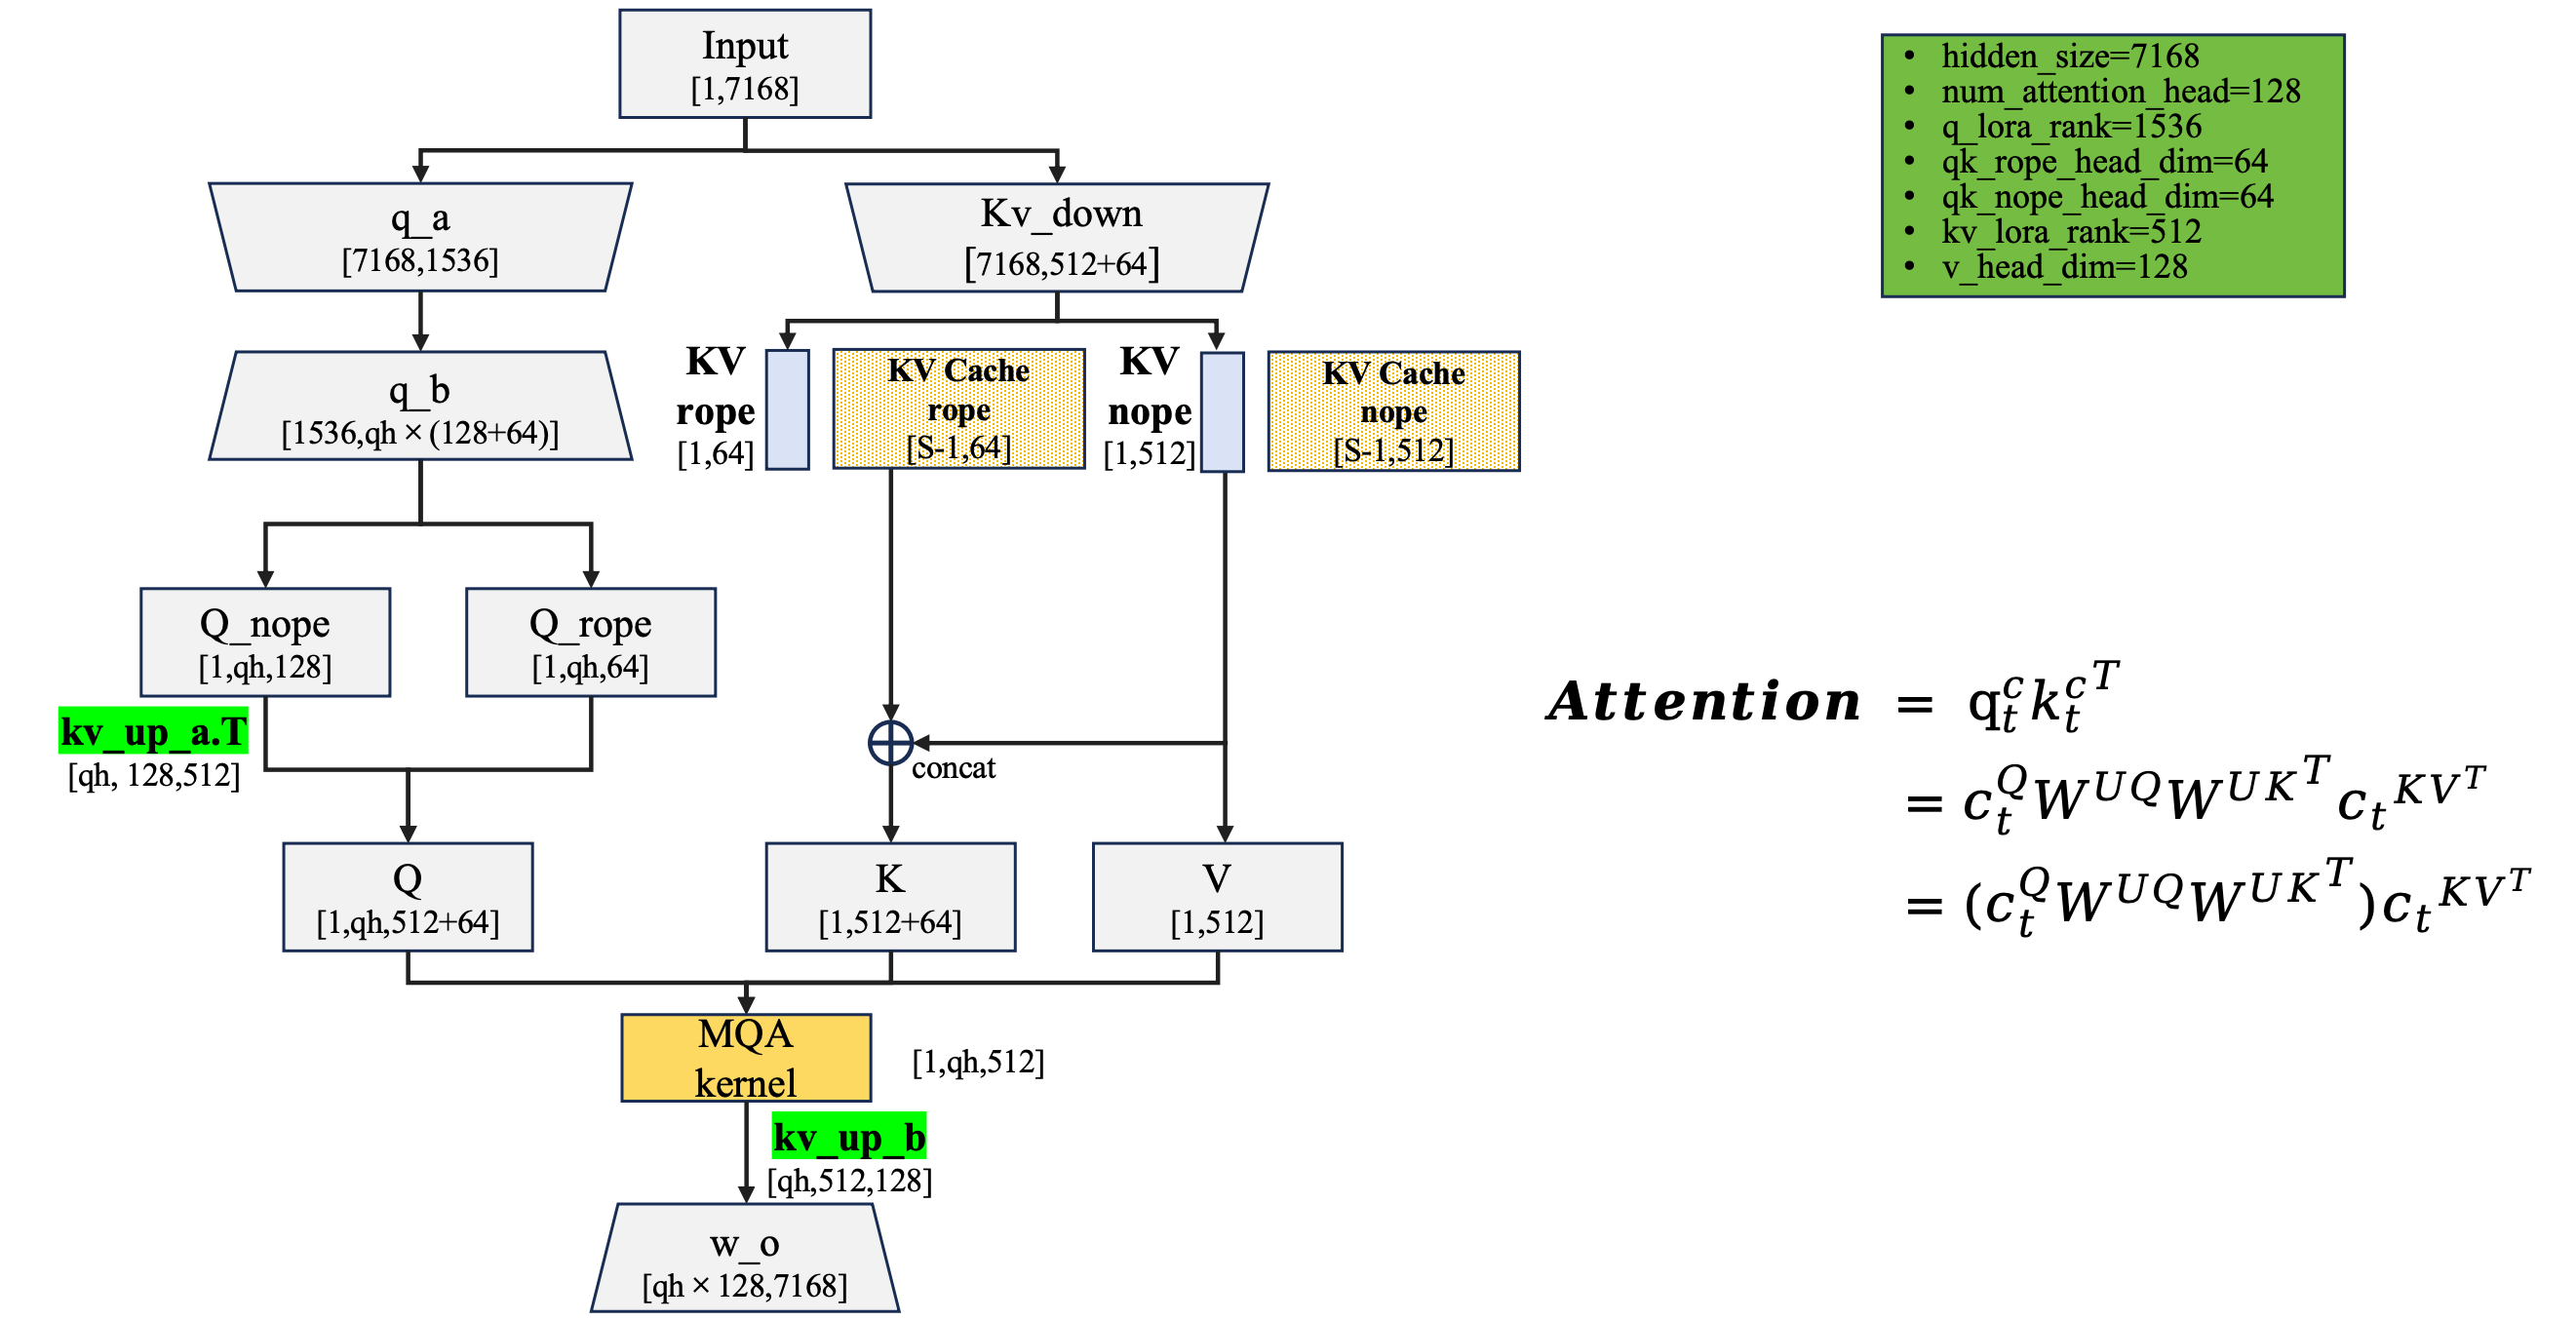

In [2]:
from IPython.display import Image, display

# 替换为你的桌面路径（关键！）
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/MLA-Decoding-No-Merge.png'  # ← 修改这里！

display(Image(filename=image_path))

In [3]:
@dataclass
class Config:
    hidden_size: int
    n_heads: int
    max_pos: int
    rope_theta: float
    rope_head_dim: int
    q_lora_rank: int
    kv_lora_rank: int
    head_dim: int
    dropout: float


In [4]:
class MLADecodingV2(nn.Module):
    """MLA Decoding 顺序吸收版的核心实现"""

    def __init__(self, config):
        super().__init__()

        self.dropout = config.dropout
        self.hidden_size = config.hidden_size
        self.n_heads = config.n_heads
        self.max_pos = config.max_pos
        self.rope_theta = config.rope_theta

        # 对应于query压缩的向量，在deepseek v3中，hidden_size 7168
        # 压缩后的kv d_c=512, 压缩比例 1/14
        # q的压缩为1536，压缩比例为 1/4.7
        # rope的维度是 64

        # 对应 query 的压缩向量
        self.q_lora_rank = config.q_lora_rank

        # 对应query 和 key进行rope的维度
        self.rope_head_dim = config.rope_head_dim

        # 对应 key, value的压缩向量
        self.kv_lora_rank = config.kv_lora_rank

        # 对应每一个head的维度
        self.head_dim = config.head_dim

        # 对应Q， K做attention的维度，nope_dim + rope_dim
        self.q_head_dim = config.head_dim + config.rope_head_dim

        # Q的降维和升维
        self.q_down_proj = nn.Linear(
            self.hidden_size,
            self.q_lora_rank,
            bias=False
        )

        self.q_up_proj = nn.Linear(
            self.q_lora_rank,
            self.n_heads * self.q_head_dim,
            bias=False
        )

        # KV的降维和升维
        self.kv_down_proj = nn.Linear(
            self.hidden_size,
            self.kv_lora_rank + self.rope_head_dim,
            bias=False
        )

        self.kv_up_proj = nn.Linear(
            self.kv_lora_rank,
            self.n_heads * (self.head_dim + self.head_dim),
            # 最终还需要做切分，一部分是K的，一部分是V的
            bias=False
        )

        # 输出映射层 O
        self.o_proj = nn.Linear(
            self.n_heads * self.head_dim,
            self.hidden_size,
            bias=False
        )

        # 初始化 ROPE 的类
        self.rotary_emb = ROPE(
            self.rope_head_dim,
            self.max_pos,
            self.rope_theta
        )

    def forward(
        self,
        hidden_states,
        attention_mask = None,
        position_ids = None,
        compressed_kv = None
    ):
        """
        MLA Decoding阶段的核心实现
        """
        bsz, q_len, _ = hidden_states.size()

        # 1. Q的降维升维映射，以及NOPE和ROPE切分
        q = self.q_up_proj(self.q_down_proj(hidden_states))
        #Q shape:[bsz, q_len, self.n_heads, self.q_head_dim]
        q = q.view(bsz, q_len, self.n_heads, self.q_head_dim).transpose(1, 2)
        q_nope, q_pe = torch.split(q,
            [self.head_dim, self.rope_head_dim],
            dim=-1
        )

        # 2.KV的降维升维映射，以及NOPE和ROPE切分
        compressed_kv_new = self.kv_down_proj(hidden_states)
        compressed_kv = torch.concat([compressed_kv, compressed_kv_new], dim=1)
        kv_seq_len = compressed_kv.size(1)
        compressed_kv, k_pe = torch.split(compressed_kv,
            [self.kv_lora_rank, self.rope_head_dim],
            dim=-1
        )
        # 构造一个head的维度 最开始是一个头
        k_pe = k_pe.view(bsz, kv_seq_len, 1, self.rope_head_dim).transpose(1, 2)
        # w_uk + w_uv
        kv_up_proj = self.kv_up_proj.weight.view(self.n_heads, -1, self.kv_lora_rank)
        # 取出W_UK, W_UV，然后用来顺序做矩阵吸收
        w_uk = kv_up_proj[:, :self.head_dim, :]
        w_uv = kv_up_proj[:, self.head_dim:, :]

        # 3. 给 q_pe 分别Apply ROPE
        cos, sin = self.rotary_emb(q_pe)
        q_pe = apply_rotary_pos_emb(q_pe, cos, sin, position_ids)
        print("q pe shape: ", q_pe.shape)
        print("k pe shape: ", k_pe.shape)
        print("q_nope shape: ", q_nope.shape)

        # 这里顺序吸收做一次矩阵乘法
        q_nope = torch.matmul(q_nope, w_uk)

        # 4. 组合 query和 key ROPE 的部分和 NOPE 的部分
        q_merge = torch.concat([q_pe, q_nope], dim=-1)
        k_merge = torch.concat([k_pe, compressed_kv.unsqueeze(-3)], dim=-1)

        # 5. 计算注意力得分
        attn_weights = torch.matmul(q_merge, k_merge.transpose(2, 3))
        attn_weights = attn_weights / math.sqrt(self.q_head_dim)

        # 6. 计算Softmax 和 dropout
        attn_weights = F.softmax(
            attn_weights, dim=-1, dtype=torch.float32
        ).to(q_nope.dtype)
        attn_weights = F.dropout(attn_weights, p=self.dropout, training=self.training)

        # 7. 计算注意力输出
        attn_output = torch.einsum("bnql,blc->bnqc", attn_weights, compressed_kv)
        attn_output = torch.matmul(attn_output, w_uv.mT)
        attn_output = attn_output.transpose(1, 2).reshape(bsz, q_len, -1)

        # 对于O也是顺序计算
        attn_output = self.o_proj(attn_output)

        return attn_output, attn_weights,q_merge

In [5]:
import numpy as np
torch.random.manual_seed(42)

config = Config(
    hidden_size=7168,
    n_heads=128,
    max_pos=1024,
    rope_theta=50000,
    rope_head_dim=64,
    q_lora_rank=1536,
    kv_lora_rank=512,
    head_dim=128,
    dropout=0.1
)
print(config)

# 定义参数
batch_size = 2
q_len = 1
kv_seq_len = 10

# 生成测试数据
q = torch.randn(batch_size, q_len, config.hidden_size)

# 构造position_ids, 这里注意和prefill的区别，输入只有最新的一个Q，即只有一个token
position_ids = torch.full((batch_size, q_len), kv_seq_len, dtype=torch.long)
print(position_ids)

# 构造compressed_kv，加载prefill阶段的c_KV, K_R
compressed_kv = torch.FloatTensor((np.load("mla_cache.npy")))
print("compressed_kv shape: ", compressed_kv.shape)

# 初始化模型
model = MLADecodingV2(config)

# 解码
attn_output, attn_weights = model(q, None, position_ids, compressed_kv)
print("attn_weights shape: ", attn_weights.shape)
print("attn_output shape: ", attn_output.shape)
print("attn_output: ", attn_output)

Config(hidden_size=7168, n_heads=128, max_pos=1024, rope_theta=50000, rope_head_dim=64, q_lora_rank=1536, kv_lora_rank=512, head_dim=128, dropout=0.1)
tensor([[10],
        [10]])
compressed_kv shape:  torch.Size([2, 10, 576])
q pe shape:  torch.Size([2, 128, 1, 64])
k pe shape:  torch.Size([2, 1, 11, 64])
q_nope shape:  torch.Size([2, 128, 1, 128])
attn_weights shape:  torch.Size([2, 128, 1, 11])
attn_output shape:  torch.Size([2, 1, 7168])
attn_output:  tensor([[[ 0.0760,  0.0165,  0.0027,  ...,  0.0122,  0.0626, -0.0084]],

        [[ 0.1070, -0.0210, -0.0962,  ...,  0.0841,  0.1056,  0.0769]]],
       grad_fn=<UnsafeViewBackward0>)
